In [35]:
!pip install kagglehub
import kagglehub
import pandas as pd
import numpy as np

path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
Dataset downloaded to: /kaggle/input/ames-housing-dataset


In [36]:
import os
print(os.listdir(path))

['AmesHousing.csv']


In [37]:
df = pd.read_csv(f"{path}/AmesHousing.csv")

In [38]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [40]:
df.shape

(2930, 82)

In [41]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing>0]
print(missing)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
dtype: int64


In [42]:

mask = df['Garage Type'].notnull() & df['Garage Qual'].isnull()
print(df[mask][['Garage Type', 'Garage Qual', 'Garage Cond', 'Garage Finish', 'Garage Yr Blt', 'Garage Cars', 'Garage Area']])

     Garage Type Garage Qual Garage Cond Garage Finish  Garage Yr Blt  \
1356      Detchd         NaN         NaN           NaN            NaN   
2236      Detchd         NaN         NaN           NaN            NaN   

      Garage Cars  Garage Area  
1356          1.0        360.0  
2236          NaN          NaN  


In [43]:
mask_bsmt = df['Bsmt Qual'].notnull() & df['Bsmt Exposure'].isnull()
print(df[mask_bsmt][['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']])

     Bsmt Qual Bsmt Cond Bsmt Exposure BsmtFin Type 1 BsmtFin Type 2
66          Gd        TA           NaN            Unf            Unf
1796        Gd        TA           NaN            Unf            Unf
2779        Gd        TA           NaN            Unf            Unf


In [44]:
category_cols = ['Pool QC','Misc Feature','Alley','Fence','Mas Vnr Type','Fireplace Qu']
for col in category_cols:
  df[col]=df[col].fillna('None')

In [45]:
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

In [46]:
mode_fill_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']
for col in mode_fill_cols:
  df.loc[1356,col] = df[col].mode()[0]

In [47]:
garage_cat_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']
for col in garage_cat_cols:
  df[col]=df[col].fillna('None')

In [48]:
df['Garage Cars'] = df['Garage Cars'].fillna(0)
df['Garage Area'] = df['Garage Area'].fillna(0)
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

In [49]:
mode_val = df['Bsmt Exposure'].mode()[0]
df.loc[mask_bsmt, 'Bsmt Exposure'] = df.loc[mask_bsmt, 'Bsmt Exposure'].fillna(mode_val)

In [50]:
mask_fin2 = df['Bsmt Qual'].notnull() & df['BsmtFin Type 2'].isnull()
print(df[mask_fin2][['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']])

    Bsmt Qual Bsmt Cond Bsmt Exposure BsmtFin Type 1 BsmtFin Type 2
444        Gd        TA            No            GLQ            NaN


In [51]:
mode_val_2 = df['BsmtFin Type 2'].mode()[0]
df.loc[mask_fin2, 'BsmtFin Type 2'] = df.loc[mask_fin2, 'BsmtFin Type 2'].fillna(mode_val_2)

In [52]:
bsmt_cat_cols = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
for col in bsmt_cat_cols:
  df[col]=df[col].fillna('None')

In [53]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing>0]
print(missing)

Mas Vnr Area      23
Lot Frontage       3
Bsmt Half Bath     2
Bsmt Full Bath     2
Total Bsmt SF      1
BsmtFin SF 2       1
Bsmt Unf SF        1
Electrical         1
BsmtFin SF 1       1
dtype: int64


In [54]:
# check which neighborhoods these 3 belong to
print(df[df['Lot Frontage'].isnull()][['Neighborhood', 'Lot Frontage']])

     Neighborhood  Lot Frontage
2256      GrnHill           NaN
2788      Landmrk           NaN
2892      GrnHill           NaN


In [55]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

In [56]:
print(df[df['Mas Vnr Area'].isnull()]['Mas Vnr Type'].value_counts(dropna=False))

Mas Vnr Type
None    23
Name: count, dtype: int64


In [57]:
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

In [58]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing>0]
print(missing)

Bsmt Half Bath    2
Bsmt Full Bath    2
Bsmt Unf SF       1
Total Bsmt SF     1
BsmtFin SF 1      1
Electrical        1
BsmtFin SF 2      1
dtype: int64


In [59]:
cols_to_check = ['Bsmt Full Bath', 'Bsmt Half Bath', 'Total Bsmt SF', 'Bsmt Unf SF', 'BsmtFin SF 1', 'BsmtFin SF 2']
print(df[df['Bsmt Full Bath'].isnull()][['Bsmt Qual', 'Bsmt Cond'] + cols_to_check])

     Bsmt Qual Bsmt Cond  Bsmt Full Bath  Bsmt Half Bath  Total Bsmt SF  \
1341      None      None             NaN             NaN            NaN   
1497      None      None             NaN             NaN            0.0   

      Bsmt Unf SF  BsmtFin SF 1  BsmtFin SF 2  
1341          NaN           NaN           NaN  
1497          0.0           0.0           0.0  


In [60]:
bsmt_num_cols = ['Bsmt Full Bath','Bsmt Half Bath','Total Bsmt SF', 'Bsmt Unf SF', 'BsmtFin SF 1', 'BsmtFin SF 2']
for col in bsmt_num_cols:
  df[col] = df[col].fillna(0)


In [61]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [62]:
df.isnull().sum().sum()

np.int64(0)

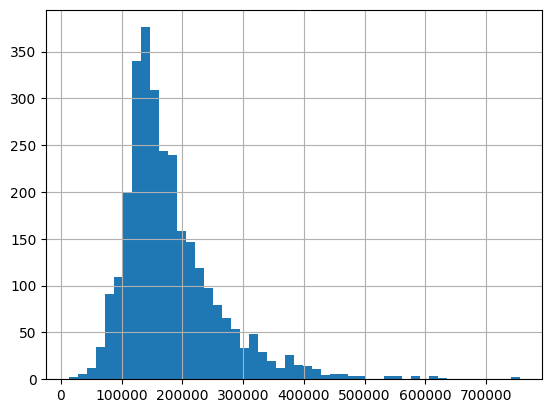

Skewness: 1.7435000757376466


In [63]:
import matplotlib.pyplot as plt
df['SalePrice'].hist(bins=50)
plt.show()
print("Skewness:", df['SalePrice'].skew())

In [66]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])


In [67]:
X = df.drop(['SalePrice', 'SalePrice_log', 'Order', 'PID'], axis=1)
y = df['SalePrice_log']


In [68]:
X = pd.get_dummies(X, drop_first=True)

In [69]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
from sklearn.linear_model import SGDRegressor
sgd = SGDRegressor(max_iter=5000,
                   tol=1e-5,
                   penalty=None,
                   eta0=0.001,
                   learning_rate='adaptive',
                   random_state=42)
sgd.fit(X_train_scaled, y_train)

SGDRegressor(eta0=0.001, learning_rate='adaptive', max_iter=5000, penalty=None,
             random_state=42, tol=1e-05)

In [72]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_scaled, y_train)
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=5000).fit(X_train_scaled, y_train)
elastic = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5, max_iter=5000).fit(X_train_scaled, y_train)

In [84]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, name):
  for split, Xd, yd in [('Train', X_train_scaled, y_train), ('Test', X_test_scaled, y_test)]:
    pred = model.predict(Xd)
    print(f"{name} {split} -> MAE:{mean_absolute_error(yd, pred):.4f} "
    f"RMSE:{np.sqrt(mean_squared_error(yd,pred)):.4f} R2:{r2_score(yd, pred):.4f}")

for m, n in [(sgd, 'SGD'), (ridge, 'Ridge'), (lasso, 'Lasso'), (elastic, 'ElasticNet')]:
  evaluate(m, n)

SGD Train -> MAE:6.6905 RMSE:11.0361 R2:-127248.5030
SGD Test -> MAE:7.0556 RMSE:11.7212 R2:-127053.8873
Ridge Train -> MAE:0.0060 RMSE:0.0092 R2:0.9124
Ridge Test -> MAE:0.0064 RMSE:0.0096 R2:0.9155
Lasso Train -> MAE:0.0072 RMSE:0.0109 R2:0.8753
Lasso Test -> MAE:0.0072 RMSE:0.0104 R2:0.9001
ElasticNet Train -> MAE:0.0062 RMSE:0.0094 R2:0.9074
ElasticNet Test -> MAE:0.0063 RMSE:0.0101 R2:0.9064


In [74]:
print("Lasso zeroed out", np.sum(lasso.coef_ == 0), "out of", len(lasso.coef_), "features")

Lasso zeroed out 234 out of 275 features
